# Statistical Inference and Maximum Likelihood

A finite sample provides information about an unknown population, but its estimates vary across possible samples. This notebook develops that distinction and explains how estimators, sampling distributions and likelihood support inference.

I assume iid observations from a specified distributional family. The family is an assumption, while its parameters are unknown. Simulations provide a known population against which estimation procedures can be compared.

In [1]:
from pathlib import Path
import sys
repository = Path.cwd()
if not (repository / "src" / "finstats").is_dir():
    repository = repository.parent
if not (repository / "src" / "finstats").is_dir():
    raise RuntimeError("Run from the repository root or notebooks directory")
sys.path.insert(0, str(repository / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display
from finstats.descriptive import (
    sample_mean, sample_variance, sample_standard_deviation,
    sample_skewness, sample_kurtosis,
)
plt.rcParams.update({
    "figure.figsize": (7,4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "font.size": 11, "axes.titlesize": 12,
    "legend.frameon": False, "lines.linewidth": 1.8,
})

from scipy.optimize import minimize
from finstats.inference import (bias, estimator_variance, mean_squared_error, standard_error_mean,
    mean_confidence_interval, variance_confidence_interval,
    gaussian_loglikelihood, gaussian_mle)

## 1. Statistical models and inferential problems

**Definition.** A statistical model is a family of possible population distributions,
$$\mathcal F=\{f(x;\theta):\theta\in\Theta\},$$
where $\Theta$ is the parameter space. For the Gaussian model,
$$\mathcal F=\{f(x;\mu,\sigma^2):\mu\in\mathbb R,\ \sigma^2>0\},\qquad
\theta=(\mu,\sigma^2)^\top.$$
The family is an assumption. The parameter identifies one population within it. Assuming Gaussian returns does not establish that actual returns are Gaussian.

Three inferential problems arise: **point estimation** gives a numerical estimate of a parameter. **Confidence intervals** quantify precision through repeated-sampling coverage. **Hypothesis testing** assesses whether observations are incompatible with a specified restriction. All three depend on the model and sampling assumptions.

## 2. Random samples, estimators, and estimates

Assume an independent, identically distributed random sample,
$$X_1,\ldots,X_n\overset{iid}{\sim}F_\theta.$$
An **estimator** is a function of that random sample,
$$\hat\theta_n=g(X_1,\ldots,X_n).$$
It is a random variable before observation. After observing $(x_1,\ldots,x_n)$, the number $g(x_1,\ldots,x_n)$ is a realized **estimate**. The parameter $\theta$ remains fixed. The estimator's distribution over possible samples is its **sampling distribution**, distinct from the distribution of each observation.

## 3. Bias

The bias of an estimator is
$$\operatorname{bias}(\hat\theta_n)=E[\hat\theta_n]-\theta.$$
An estimator is unbiased when its expectation equals the population parameter. For iid observations with mean $\mu$, $E[\bar X_n]=\mu$. This statement concerns the sampling distribution, rather than equality between every realized sample mean and $\mu$.

## 4. Variance and standard error


The sampling variance describes dispersion of an estimator:
$$\operatorname{Var}(\hat\theta)=E[(\hat\theta-E[\hat\theta])^2],\qquad
SE(\hat\theta)=\sqrt{\operatorname{Var}(\hat\theta)}.$$
For iid observations with finite variance,
$$\operatorname{Var}(\bar X)=\sigma^2/n,\qquad SE(\bar X)=\sigma/\sqrt n.$$
The observation variance $\sigma^2$ and estimator variance $\sigma^2/n$ describe different objects. The realized sample variance $s^2$ estimates the former. The quantity $s/\sqrt n$ estimates the mean estimator's standard error.

## 5. Mean-squared error

Mean-squared error measures squared estimation error averaged over random samples:
$$\operatorname{MSE}(\hat\theta_n)=E[(\hat\theta_n-\theta)^2]
=\operatorname{Var}(\hat\theta_n)+\operatorname{bias}(\hat\theta_n)^2.$$
To obtain the decomposition, write the error as $(\hat\theta_n-E[\hat\theta_n])+(E[\hat\theta_n]-\theta)$. The cross term has expectation zero.

MSE combines dispersion and bias, so a smaller variance can compensate for some bias. Zero MSE requires both zero variance and zero bias. Unbiasedness alone does not imply zero MSE. For the sample mean, $\operatorname{MSE}(\bar X_n)=\sigma^2/n$.

## 6. Consistency

An estimator is consistent when
$$\hat\theta_n\xrightarrow{P}\theta,\qquad
\lim_{n\to\infty}P(|\hat\theta_n-\theta|\ge\varepsilon)=0\quad\text{for every }\varepsilon>0.$$
MSE consistency means $\operatorname{MSE}(\hat\theta_n)\to0$. It implies consistency in probability, but the converse need not hold. The sample mean is MSE-consistent under iid sampling with finite variance, because $\sigma^2/n\to0$. Unbiasedness and consistency describe different properties.

## 7. Sampling distributions under the Gaussian model

For an iid sample $X_1,\ldots,X_n$ from $N(\mu,\sigma^2)$,
$$\bar X_n\sim N(\mu,\sigma^2/n),\qquad
S_n^2=\frac1{n-1}\sum_i(X_i-\bar X_n)^2,$$
$$\frac{(n-1)S_n^2}{\sigma^2}\sim\chi^2_{n-1},\qquad
\frac{\bar X_n-\mu}{S_n/\sqrt n}\sim t_{n-1}.$$
The adjusted sample variance is unbiased and consistent. A chi-squared variable with $k$ degrees of freedom is the sum of squares of $k$ independent standard Gaussian variables. The Student-t pivot accounts for replacing the unknown observation variance by its sample estimate.

For illustration, I use 3000 independent samples from $N(5,4)$ at $n=20,100,1000$, with seed 303. The figure shows concentration of sample means around the fixed mean. The table compares Monte Carlo bias, sampling variance and MSE with their population values. Observation variance remains four at every sample size.

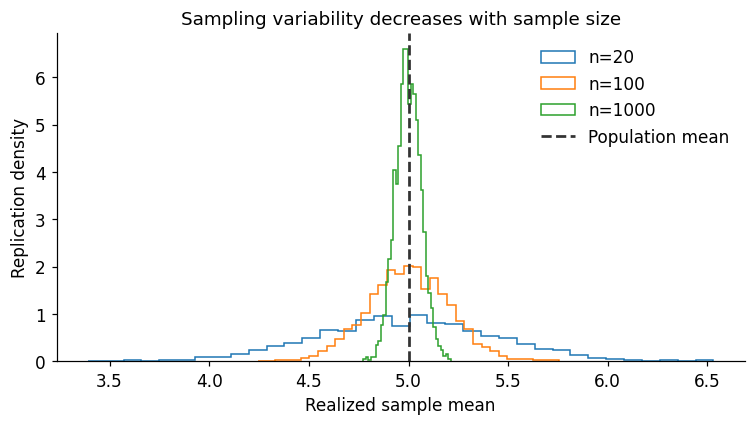

,n,MC bias (target 0),MC variance,Population variance / MSE,MC MSE
0,20,-0.017148,0.197314,0.200,0.197543
1,100,-0.001113,0.041315,0.040,0.041303
2,1000,-0.000785,0.004035,0.004,0.004034


In [2]:
population_mu, population_variance = 5., 4.
rng_sampling = np.random.default_rng(303)
sampling_results = {}
rows = []
fig, ax = plt.subplots()
for n in (20, 100, 1000):
    samples = rng_sampling.normal(5, 2, size=(3000, n))
    estimates = np.array([sample_mean(row) for row in samples])
    sampling_results[n] = estimates
    ax.hist(estimates, bins=35, density=True, histtype="step", label=f"n={n}")
    rows.append([n, bias(estimates, 5), estimator_variance(estimates), 4/n, mean_squared_error(estimates, 5)])
ax.axvline(5, color="0.2", linestyle="--", label="Population mean")
ax.set(xlabel="Realized sample mean", ylabel="Replication density", title="Sampling variability decreases with sample size")
ax.legend()
fig.tight_layout()
plt.show()
display(pd.DataFrame(rows, columns=["n", "MC bias (target 0)", "MC variance", "Population variance / MSE", "MC MSE"]))

## 8. Confidence intervals

A confidence interval has random endpoints calculated from the sample:
$$C_n=[L_n,U_n],\qquad P_\theta(\theta\in C_n)=1-\alpha.$$
The parameter is fixed. Repeated sampling generates intervals that cover it with the stated probability. Once the sample is observed, $c_n=[l_n,u_n]$ is fixed and either contains the parameter or does not.

For Gaussian observations with known $\sigma$, the interval for $\mu$ is
$$\bar X_n\pm z_{1-\alpha/2}\frac{\sigma}{\sqrt n}.$$
With unknown variance, the exact Gaussian intervals are
$$\bar X_n\pm t_{1-\alpha/2,n-1}\frac{S_n}{\sqrt n},$$
$$\left[\frac{(n-1)S_n^2}{\chi^2_{1-\alpha/2,n-1}},
\frac{(n-1)S_n^2}{\chi^2_{\alpha/2,n-1}}\right].$$
Their calibration depends on iid Gaussian sampling. For illustration, I calculate realized 95% intervals from a size-ten sample of $N(5,4)$ with seed 314. I later use the same sample for the likelihood, so the uncertainty and estimation calculations concern the same observations.

In [3]:
alpha = .05
likelihood_sample = np.random.default_rng(314).normal(5, 2, size=10)
mean_interval = mean_confidence_interval(likelihood_sample, alpha)
variance_interval = variance_confidence_interval(likelihood_sample, alpha)
display(pd.DataFrame([mean_interval, variance_interval], index=["Mean μ", "Variance σ²"], columns=["Lower endpoint", "Upper endpoint"]))

,Lower endpoint,Upper endpoint
Mean μ,4.408649,5.713162
Variance σ²,0.393333,2.770815


## 9. Hypothesis testing

A null hypothesis $H_0:\theta\in\Theta_0$ is compared with an alternative $H_1:\theta\in\Theta_1$. A statistic $T_n$ and rejection region $C_\alpha$ define the test. The significance level controls Type I error:
$$P_\theta(T_n\in C_\alpha)\le\alpha,\qquad\theta\in\Theta_0.$$
Type I error means rejecting a true null, while Type II error means failing to reject a false null. A p-value is the null probability of a statistic at least as extreme as the observed one. It is not the probability that the null hypothesis is true.

For iid $N(\theta,\sigma^2)$ observations with known $\sigma$, test $H_0:\theta=\mu_0$ against $H_1:\theta\ne\mu_0$ using
$$Z=\frac{\bar X_n-\mu_0}{\sigma/\sqrt n},\qquad C_\alpha=\{|Z|>z_{1-\alpha/2}\}.$$
The two-sided p-value is $2[1-\Phi(|z_{obs}|)]$.

In the return example, $n=100$, $\sigma=.02$, $\bar x=.005$ and $\mu_0=0$. Then $z_{obs}=2.5$ and the p-value is approximately $.0124$. At the 5% level this is evidence against a zero population mean under the assumed model.

In [4]:
alpha = .05
observed_mean, known_sigma, observed_n = .005, .02, 100
observed_se = standard_error_mean(known_sigma, observed_n)
z_observed = observed_mean/observed_se
p_value = 2*stats.norm.sf(abs(z_observed))
z_critical = stats.norm.ppf(1-alpha/2)
print(f"z={z_observed:.3f}, p-value={p_value:.4f}")
print("95% known-variance mean interval:",
      np.round([observed_mean-z_critical*observed_se, observed_mean+z_critical*observed_se], 6))

z=2.500, p-value=0.0124
95% known-variance mean interval: [0.00108 0.00892]


## 10. Likelihood

Let $Y_1,\ldots,Y_n$ be iid with density or mass function $f(y;\theta)$. For observed values $y_1,\ldots,y_n$, the likelihood is the joint density or mass viewed as a function of $\theta$:
$$L(\theta;y)=\prod_{i=1}^n f(y_i;\theta),\qquad
\ell(\theta;y)=\sum_{i=1}^n\log f(y_i;\theta).$$
The sample is fixed when comparing parameter values. A likelihood is not a probability distribution over parameters. Its logarithm preserves the maximizing parameter.

## 11. Maximum likelihood estimation

The estimate maximizes likelihood for the observed sample:
$$\hat\theta_{ML}(y)=\operatorname*{arg\,max}_{\theta\in\Theta}L(\theta;y)
=\operatorname*{arg\,max}_{\theta\in\Theta}\ell(\theta;y).$$
Before observing the sample, $\hat\theta_{ML}(Y)$ is an estimator and therefore a random variable.

### Gaussian MLE

Some models give closed-form estimates. Consider iid Gaussian observations with $\theta=(\mu,v)^\top$, where $v=\sigma^2>0$:
$$\ell(\mu,v)=-\frac n2\log(2\pi v)-\frac1{2v}\sum_i(x_i-\mu)^2.$$
The partial derivatives are
$$\frac{\partial\ell}{\partial\mu}=\frac1v\sum_i(x_i-\mu),\qquad
\frac{\partial\ell}{\partial v}=-\frac n{2v}+\frac1{2v^2}\sum_i(x_i-\mu)^2.$$
Setting them to zero gives
$$\hat\mu_{ML}=\bar X,\qquad \hat v_{ML}=\frac1n\sum_i(X_i-\bar X)^2.$$
At the maximum,
$$H(\hat\mu,\hat v)=\begin{pmatrix}-n/\hat v&0\\0&-n/(2\hat v^2)\end{pmatrix}.$$
It is negative definite for a nonconstant sample, which confirms a strict local maximum. The identity
$$\sum_i(x_i-\mu)^2=\sum_i(x_i-\bar x)^2+n(\mu-\bar x)^2$$
shows that $\bar x$ maximizes the likelihood at every fixed $v$. The variance profile then increases up to $\hat v$ and decreases afterward, establishing the global maximum. A constant sample has no finite maximum for $v>0$.

The variance MLE uses denominator $n$, whereas $S^2$ uses $n-1$:
$$\hat v_{ML}=\frac{n-1}{n}S^2,\qquad \operatorname{Bias}(\hat v_{ML})=-v/n.$$
Maximum likelihood therefore need not give an unbiased estimator.

For illustration, I use one iid sample of size ten from $N(5,4)$, with seed 314, already used for the confidence intervals. The likelihood peak is sample-specific, which makes it distinct from the generating parameter.

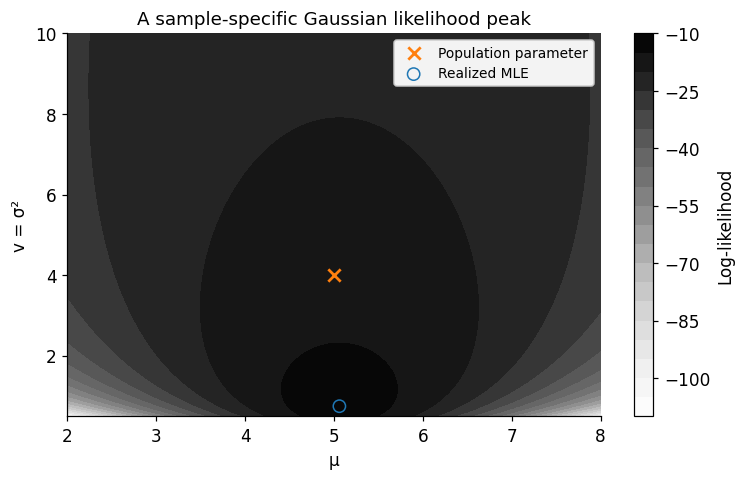

Population (μ, variance): (5, 4)
Realized Gaussian MLE: [5.06090549 0.74822786]
Adjusted sample variance: 0.831364; variance MLE: 0.748228


In [5]:
analytical_mle = np.array(gaussian_mle(likelihood_sample))
mu_axis = np.linspace(2, 8, 101)
variance_axis = np.linspace(.5, 10, 101)
mu_mesh, variance_mesh = np.meshgrid(mu_axis, variance_axis)
log_surface = np.array([gaussian_loglikelihood([mu, v], likelihood_sample)
    for mu, v in zip(mu_mesh.ravel(), variance_mesh.ravel())]).reshape(mu_mesh.shape)
fig, ax = plt.subplots(figsize=(7, 4.5))
contours = ax.contourf(mu_mesh, variance_mesh, log_surface, levels=18, cmap="Greys")
fig.colorbar(contours, ax=ax, label="Log-likelihood")
ax.scatter([5], [4], marker="x", color="C1", s=65, label="Population parameter")
ax.scatter([analytical_mle[0]], [analytical_mle[1]], marker="o", facecolors="none", edgecolors="C0", s=65, label="Realized MLE")
ax.set(xlabel="μ", ylabel="v = σ²", title="A sample-specific Gaussian likelihood peak")
ax.legend(frameon=True, facecolor="white", framealpha=.95, fontsize=9)
fig.tight_layout()
plt.show()
print("Population (μ, variance):", (5, 4))
print("Realized Gaussian MLE:", analytical_mle)
print(f"Adjusted sample variance: {sample_variance(likelihood_sample):.6f}; variance MLE: {analytical_mle[1]:.6f}")

### Numerical verification

The Gaussian solution is analytical. For illustration, I maximize the same log-likelihood numerically and compare the result with the closed-form estimate. A log-variance parameter keeps variance positive. Agreement checks the computation for this sample, rather than providing a general guarantee about optimization.

In [6]:
def negative_gaussian_loglikelihood(parameters):
    mu, log_variance = parameters
    return -gaussian_loglikelihood([mu, np.exp(log_variance)], likelihood_sample)

result = minimize(negative_gaussian_loglikelihood, [4., np.log(3.)], method="BFGS")
if not result.success:
    raise RuntimeError(result.message)
numerical_mle = np.array([result.x[0], np.exp(result.x[1])])
np.testing.assert_allclose(numerical_mle, analytical_mle, rtol=1e-5, atol=1e-5)
display(pd.DataFrame([analytical_mle, numerical_mle], index=["Analytical", "Numerical"], columns=["Mean μ", "Variance σ²"]))

,Mean μ,Variance σ²
Analytical,5.060905,0.748228
Numerical,5.060905,0.748228


### Fisher information and asymptotic precision

The score and expected Fisher information for the full sample are
$$U_n(\theta)=\frac{\partial\ell_n(\theta)}{\partial\theta},\qquad
I_n(\theta)=E[U_nU_n^\top]=-E\left[\frac{\partial^2\ell_n}{\partial\theta\partial\theta^\top}\right].$$
Under the regularity conditions for a regular iid model, $I_n=nI_1$ and
$$\sqrt n(\hat\theta_{ML}-\theta)\xrightarrow{d}N(0,I_1(\theta)^{-1}).$$
Thus the unscaled estimator is approximately $N(\theta,I_n(\theta)^{-1})$ for large $n$. The distinction between single-observation information $I_1$ and sample information $I_n$ makes the scaling explicit.

The inverse expected information at the estimate, or the inverse observed information $-H_n(\hat\theta)$, supplies an approximate sampling covariance matrix. Standard errors are the square roots of its diagonal entries. For the Gaussian parameterization $\theta=(\mu,v)^\top$, $v=\sigma^2$,
$$I_n(\mu,v)=\begin{pmatrix}n/v&0\\0&n/(2v^2)\end{pmatrix},\qquad
\widehat{se}(\hat\mu)=\sqrt{\hat v/n},\qquad
\widehat{se}(\hat v)=\sqrt{2\hat v^2/n}.$$

Approximate intervals use $\hat\theta_j\pm z_{1-\alpha/2}\widehat{se}(\hat\theta_j)$. These are large-sample statements, unlike the exact Gaussian intervals above. Consistency and asymptotic normality require conditions such as identification, an interior true parameter, a smooth likelihood and finite nonsingular information. The MLE of a function of the parameter is the same function of the MLE, when that target is identifiable.

In [7]:
mle_mu, mle_v = analytical_mle
likelihood_n = len(likelihood_sample)
residual_sum = np.sum(likelihood_sample-mle_mu)
residual_square_sum = np.sum((likelihood_sample-mle_mu)**2)
score_at_mle = np.array([residual_sum/mle_v,-likelihood_n/(2*mle_v)+residual_square_sum/(2*mle_v**2)])
hessian_at_mle = np.array([
    [-likelihood_n/mle_v,-residual_sum/mle_v**2],
    [-residual_sum/mle_v**2,likelihood_n/(2*mle_v**2)-residual_square_sum/mle_v**3],
])
observed_information = -hessian_at_mle
estimated_mle_covariance = np.linalg.inv(observed_information)
print("Score at MLE:",score_at_mle)
print("Observed information eigenvalues:",np.linalg.eigvalsh(observed_information))
print("Estimated SEs of (μ MLE, variance MLE):",np.sqrt(np.diag(estimated_mle_covariance)))
np.testing.assert_allclose(observed_information,np.diag([likelihood_n/mle_v,likelihood_n/(2*mle_v**2)]),atol=1e-12)

Score at MLE: [-4.15464946e-15  0.00000000e+00]
Observed information eigenvalues: [ 8.93104454 13.36491267]
Estimated SEs of (μ MLE, variance MLE): [0.27353754 0.33461767]
